In [32]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

## Load dataset

In [33]:
df = pd.read_csv('SuperStoreOrders.csv')
df

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year
0,AG-2011-2040,1/1/2011,6/1/2011,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,Office Supplies,Storage,"Tenex Lockers, Blue",408,2,0.0,106.1400,35.46,Medium,2011
1,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Office Supplies,Supplies,"Acme Trimmer, High Speed",120,3,0.1,36.0360,9.72,Medium,2011
2,HU-2011-1220,1/1/2011,5/1/2011,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,Office Supplies,Storage,"Tenex Box, Single Width",66,4,0.0,29.6400,8.17,High,2011
3,IT-2011-3647632,1/1/2011,5/1/2011,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,...,Office Supplies,Paper,"Enermax Note Cards, Premium",45,3,0.5,-26.0550,4.82,High,2011
4,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Furniture,Furnishings,"Eldon Light Bulb, Duo Pack",114,5,0.1,37.7700,4.70,Medium,2011
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51285,CA-2014-115427,31-12-2014,4/1/2015,Standard Class,Erica Bern,Corporate,California,United States,US,West,...,Office Supplies,Binders,"Cardinal Slant-D Ring Binder, Heavy Gauge Vinyl",14,2,0.2,4.5188,0.89,Medium,2014
51286,MO-2014-2560,31-12-2014,5/1/2015,Standard Class,Liz Preis,Consumer,Souss-Massa-Draâ,Morocco,Africa,Africa,...,Office Supplies,Binders,"Wilson Jones Hole Reinforcements, Clear",4,1,0.0,0.4200,0.49,Medium,2014
51287,MX-2014-110527,31-12-2014,2/1/2015,Second Class,Charlotte Melton,Consumer,Managua,Nicaragua,LATAM,Central,...,Office Supplies,Labels,"Hon Color Coded Labels, 5000 Label Set",26,3,0.0,12.3600,0.35,Medium,2014
51288,MX-2014-114783,31-12-2014,6/1/2015,Standard Class,Tamara Dahlen,Consumer,Chihuahua,Mexico,LATAM,North,...,Office Supplies,Labels,"Hon Legal Exhibit Labels, Alphabetical",7,1,0.0,0.5600,0.20,Medium,2014


In [34]:
df.columns

Index(['order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_name',
       'segment', 'state', 'country', 'market', 'region', 'product_id',
       'category', 'sub_category', 'product_name', 'sales', 'quantity',
       'discount', 'profit', 'shipping_cost', 'order_priority', 'year'],
      dtype='object')

In [35]:
df.dtypes

order_id           object
order_date         object
ship_date          object
ship_mode          object
customer_name      object
segment            object
state              object
country            object
market             object
region             object
product_id         object
category           object
sub_category       object
product_name       object
sales              object
quantity            int64
discount          float64
profit            float64
shipping_cost     float64
order_priority     object
year                int64
dtype: object

## EDA


### Data cleaning


In [36]:
df.isnull().sum()

order_id          0
order_date        0
ship_date         0
ship_mode         0
customer_name     0
segment           0
state             0
country           0
market            0
region            0
product_id        0
category          0
sub_category      0
product_name      0
sales             0
quantity          0
discount          0
profit            0
shipping_cost     0
order_priority    0
year              0
dtype: int64

In [37]:
df.dropna(subset=['sales', 'profit', 'category'], inplace=True)

In [38]:
df = df.drop_duplicates(subset="order_id", keep="first")
df

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year
0,AG-2011-2040,1/1/2011,6/1/2011,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,Office Supplies,Storage,"Tenex Lockers, Blue",408,2,0.0,106.1400,35.46,Medium,2011
1,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Office Supplies,Supplies,"Acme Trimmer, High Speed",120,3,0.1,36.0360,9.72,Medium,2011
2,HU-2011-1220,1/1/2011,5/1/2011,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,Office Supplies,Storage,"Tenex Box, Single Width",66,4,0.0,29.6400,8.17,High,2011
3,IT-2011-3647632,1/1/2011,5/1/2011,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,...,Office Supplies,Paper,"Enermax Note Cards, Premium",45,3,0.5,-26.0550,4.82,High,2011
6,CA-2011-1510,2/1/2011,6/1/2011,Standard Class,Magdelene Morse,Consumer,Ontario,Canada,Canada,Canada,...,Technology,Machines,"Okidata Inkjet, Wireless",314,1,0.0,3.1200,24.10,Medium,2011
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51281,CA-2014-115427,31-12-2014,4/1/2015,Standard Class,Erica Bern,Corporate,California,United States,US,West,...,Office Supplies,Binders,GBC Binding covers,21,2,0.2,6.4750,2.06,Medium,2014
51282,UP-2014-4410,31-12-2014,4/1/2015,Standard Class,Guy Thornton,Consumer,Zaporizhzhya,Ukraine,EMEA,EMEA,...,Office Supplies,Labels,"Avery Round Labels, Alphabetical",28,4,0.0,6.1200,1.70,Medium,2014
51284,MX-2014-108574,31-12-2014,4/1/2015,Standard Class,Julia Barnett,Home Office,Tamaulipas,Mexico,LATAM,North,...,Office Supplies,Labels,"Novimex Legal Exhibit Labels, Adjustable",17,3,0.0,0.6600,1.32,Medium,2014
51286,MO-2014-2560,31-12-2014,5/1/2015,Standard Class,Liz Preis,Consumer,Souss-Massa-Draâ,Morocco,Africa,Africa,...,Office Supplies,Binders,"Wilson Jones Hole Reinforcements, Clear",4,1,0.0,0.4200,0.49,Medium,2014


### Overview Profit


In [39]:
df['sales'] = pd.to_numeric(
    df['sales'].astype(str).str.replace('[\$,]', '', regex=True),
)

df['profit'] = pd.to_numeric(
    df['profit'].astype(str).str.replace('[\$,]', '', regex=True)
)

In [40]:
# Basic Profit Overview
print("Total Sales:", df['sales'].sum())
print("Total Profit:", df['profit'].sum())
print("Average Profit Margin:", (df['profit'].sum() / df['sales'].sum()))

Total Sales: 9315105
Total Profit: 1076543.4658
Average Profit Margin: 0.11556965442686903


In [41]:
# Category-wise Sales & Profit
category_summary = df.groupby('category').agg(
    total_sales=('sales', 'sum'),
    total_profit=('profit', 'sum')
).reset_index()

category_summary['profit_margin'] = (
    category_summary['total_profit'] /
    category_summary['total_sales']
)

category_summary.sort_values('profit_margin')

,category,total_sales,total_profit,profit_margin
0,Furniture,3215999,214713.8195,0.066764
1,Office Supplies,2432315,327835.2511,0.134783
2,Technology,3666791,533994.3952,0.145630


## Feature Engineering


In [42]:
df['order_date'] = pd.to_datetime(
    df['order_date'], format="mixed", dayfirst=True)
df['ship_date'] = pd.to_datetime(
    df['ship_date'], format="mixed", dayfirst=True)

In [43]:
# Extract Time Features
df['year'] = df['order_date'].dt.year
df['month'] = df['order_date'].dt.month
df['quarter'] = df['order_date'].dt.quarter

In [44]:
# Profit Margin Per Transaction
df['profit_margin'] = df['profit'] / df['sales']
df['profit_margin']

0        0.260147
1        0.300300
2        0.449091
3       -0.579000
6        0.009936
           ...   
51281    0.308333
51282    0.218571
51284    0.038824
51286    0.105000
51289   -0.201600
Name: profit_margin, Length: 25035, dtype: float64

In [ ]:
# Inventory & SKU Performance Analysis
inventory_df = df.groupby('product_name').agg(
    total_quantity=('quantity', 'sum'),
    total_sales=('sales', 'sum'),
    total_profit=('profit', 'sum'),
    selling_days=('order_date', 'nunique')
).reset_index()

inventory_df['avg_daily_sales'] = (
    inventory_df['total_quantity'] / inventory_df['selling_days'])

inventory_df['inventory_days'] = (
    inventory_df['total_quantity'] / inventory_df['avg_daily_sales'])

inventory_df['profit_margin'] = (
    inventory_df['total_profit'] / inventory_df['total_sales'])


inventory_df

,product_name,total_quantity,total_sales,total_profit,selling_days,avg_daily_sales,inventory_days,profit_margin
0,"#10 Gummed Flap White Envelopes, 100/Box",2,7,2.1476,1,2.000000,1.0,0.306800
1,"#10 White Business Envelopes,4 1/8 x 9 1/2",15,226,101.0715,3,5.000000,3.0,0.447219
2,"#10- 4 1/8"" x 9 1/2"" Recycled Envelopes",17,134,55.8486,4,4.250000,4.0,0.416781
3,"#10- 4 1/8"" x 9 1/2"" Security-Tint Envelopes",7,47,20.0932,3,2.333333,3.0,0.427515
4,"#10-4 1/8"" x 9 1/2"" Premium Diagonal Seam Enve...",4,63,28.3320,1,4.000000,1.0,0.449714
...,...,...,...,...,...,...,...,...
3596,iHome FM Clock Radio with Lightning Dock,8,420,0.0000,4,2.000000,4.0,0.000000
3597,iKross Bluetooth Portable Keyboard + Cell Phon...,16,311,68.7160,3,5.333333,3.0,0.220952
3598,iOttie HLCRIO102 Car Mount,6,120,5.9970,1,6.000000,1.0,0.049975
3599,invisibleSHIELD by ZAGG Smudge-Free Screen Pro...,23,367,151.8356,5,4.600000,5.0,0.413721


## Segmentation

In [ ]:
# 6.1 Inventory Movement Segmentation
inventory_df['inventory_segment'] = pd.qcut(
    inventory_df['inventory_days'],
    q=3,
    labels=['Fast-moving','Moderate','Slow-moving']
)
inventory_df['inventory_segment'].value_counts()

inventory_segment
Fast-moving    1296
Moderate       1214
Slow-moving    1091
Name: count, dtype: int64

In [48]:
# 6.2 Profitability Segmentation
inventory_df['profit_segment'] = pd.cut(
    inventory_df['profit_margin'],
    bins=[-np.inf, 0, 0.1, np.inf],
    labels=['Loss','Low Margin','High Margin']
)
inventory_df['profit_segment'].value_counts()

profit_segment
High Margin    2280
Loss            690
Low Margin      631
Name: count, dtype: int64

In [49]:
# 6.3 Combined Risk Segmentation
inventory_df['risk_category'] = np.where(
    (inventory_df['inventory_segment']=='Slow-moving') &
    (inventory_df['profit_segment']=='Loss'),
    'High Risk',
    'Normal'
)
inventory_df['risk_category'].value_counts()

risk_category
Normal       3417
High Risk     184
Name: count, dtype: int64

## Visualizations

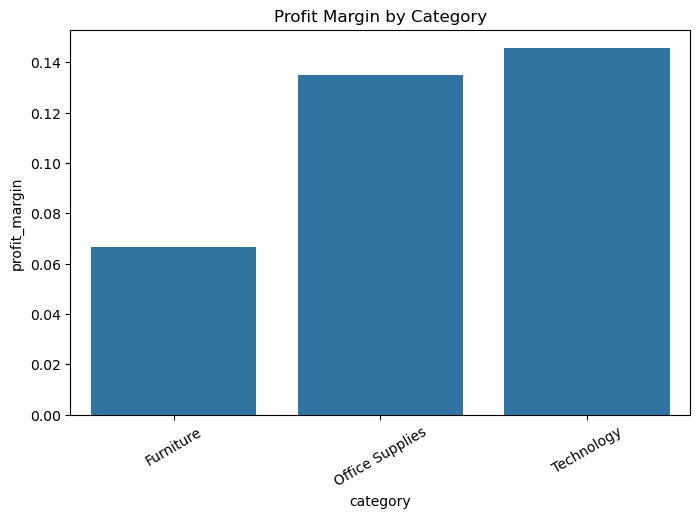

In [50]:
# Profit Margin by Category
plt.figure(figsize=(8,5))
sns.barplot(data=category_summary, x='category', y='profit_margin')
plt.title("Profit Margin by Category")
plt.xticks(rotation=30)
plt.show()

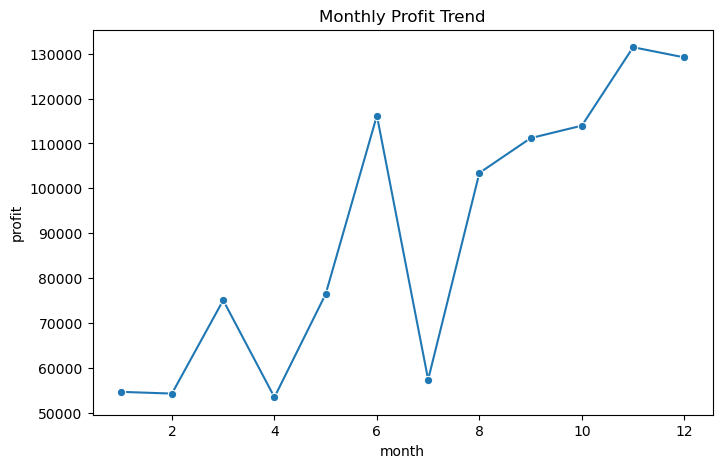

In [51]:
# Monthly Profit Trend
monthly_profit = df.groupby('month')['profit'].sum().reset_index()

plt.figure(figsize=(8,5))
sns.lineplot(data=monthly_profit, x='month', y='profit', marker='o')
plt.title("Monthly Profit Trend")
plt.show()

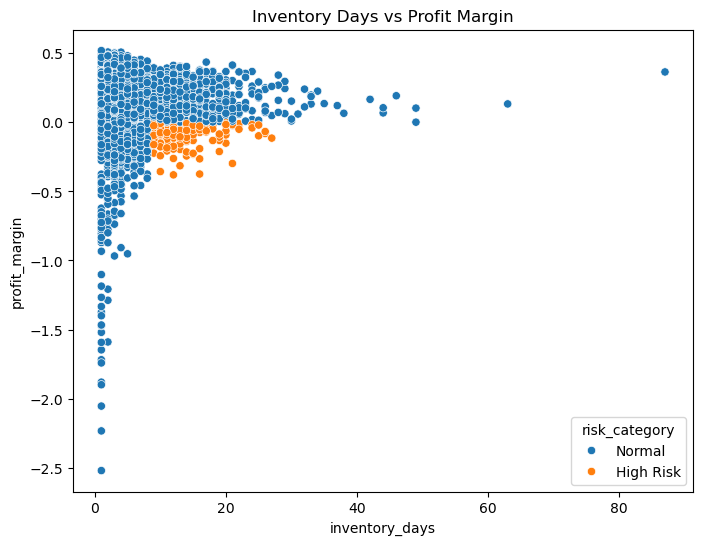

In [53]:
# Inventory Days vs Profit Margin (Risk Scatter)
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=inventory_df,
    x='inventory_days',
    y='profit_margin',
    hue='risk_category'
)
plt.title("Inventory Days vs Profit Margin")
plt.show()

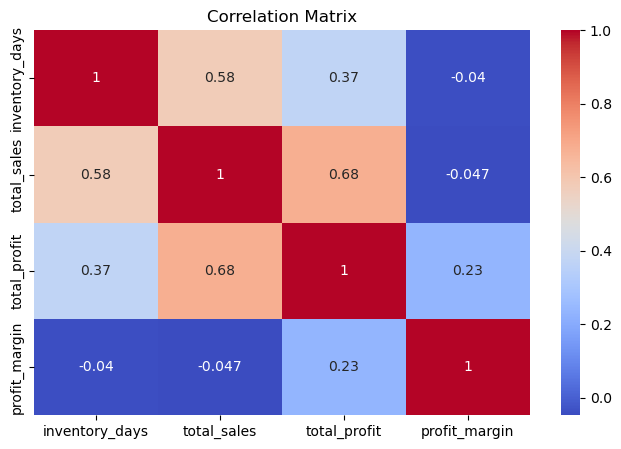

In [56]:
# Correlation Heatmap
corr = inventory_df[['inventory_days','total_sales','total_profit','profit_margin']].corr()

plt.figure(figsize=(8,5))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

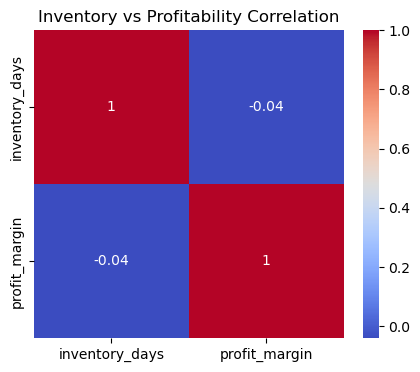

In [61]:
# Correlation Between Inventory & Profitability
corr = inventory_df[['inventory_days','profit_margin']].corr()

plt.figure(figsize=(5,4))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Inventory vs Profitability Correlation")
plt.show()

## Analysis

In [57]:
# Identify Profit-Draining Categories
category_summary.sort_values('profit_margin').head()

,category,total_sales,total_profit,profit_margin
0,Furniture,3215999,214713.8195,0.066764
1,Office Supplies,2432315,327835.2511,0.134783
2,Technology,3666791,533994.3952,0.145630


In [58]:
# Slow-Moving & Loss-Making Products
inventory_df[
    (inventory_df['inventory_segment']=='Slow-moving') &
    (inventory_df['profit_segment']=='Loss')
]

,product_name,total_quantity,total_sales,total_profit,selling_days,avg_daily_sales,inventory_days,profit_margin,inventory_segment,profit_segment,risk_category
60,"Acco Binder, Recycled",57,691,-14.7903,15,3.800000,15.0,-0.021404,Slow-moving,Loss,High Risk
99,"Accos Paper Clips, Assorted Sizes",27,253,-9.6980,9,3.000000,9.0,-0.038332,Slow-moving,Loss,High Risk
122,"Acme Box Cutter, Serrated",60,1131,-75.4900,10,6.000000,10.0,-0.066746,Slow-moving,Loss,High Risk
145,"Acme Shears, Easy Grip",41,1167,-242.3270,11,3.727273,11.0,-0.207650,Slow-moving,Loss,High Risk
183,"Advantus Frame, Black",53,3826,-180.6880,11,4.818182,11.0,-0.047226,Slow-moving,Loss,High Risk
...,...,...,...,...,...,...,...,...,...,...,...
3277,"Tenex Shelving, Blue",61,2630,-223.8820,19,3.210526,19.0,-0.085126,Slow-moving,Loss,High Risk
3280,"Tenex Shelving, Wire Frame",77,3139,-330.9425,13,5.923077,13.0,-0.105429,Slow-moving,Loss,High Risk
3363,"Wilson Jones Binder Covers, Clear",38,262,-42.3900,9,4.222222,9.0,-0.161794,Slow-moving,Loss,High Risk
3367,"Wilson Jones Binder, Clear",35,329,-61.0980,11,3.181818,11.0,-0.185708,Slow-moving,Loss,High Risk


In [59]:
# Seasonal High-Profit Months
monthly_profit.sort_values('profit', ascending=False)

,month,profit
10,11,131470.53334
11,12,129199.89726
5,6,116228.38640
9,10,113980.50920
8,9,111195.22968
7,8,103434.65598
4,5,76413.70928
2,3,75038.08890
6,7,57336.75482
0,1,54610.15466


In [62]:
# Export full cleaned dataset
df.to_csv("clean_retail_data.csv", index=False)

print("CSV file exported successfully!")

CSV file exported successfully!
